# Sprint 3 — Construcción y comparación de modelos predictivos

**Dataset:** [House price prediction (Kaggle — `shree1992/housedata`)](https://www.kaggle.com/datasets/shree1992/housedata)

**Entorno:** Google Colab — continuación de los Sprints 1 y 2.

---

## Índice

1. **Fase 1 — Modelización predictiva: definición y comparación de escenarios**
   - 1.0 Configuración, carga y preparación de datos (resumen del Sprint 2)
   - 1.1 Estrategia de evaluación (hold-out + validación cruzada)
   - 1.2 **Escenario 1** — Baseline: regresión lineal con características físicas
   - 1.3 **Escenario 2** — Regresión lineal con físicas **+ ubicación** (one-hot)
   - 1.4 **Escenario 3** — `log(price)` + escalado + **regularización** (Ridge / Lasso)
   - 1.5 **Escenario 4** — Modelo **no lineal** de contraste (Gradient Boosting / Random Forest)
   - 1.6 Comparación global y conclusiones de la Fase 1
2. **Fase 2** — Primer diseño de la solución en la nube *(entrega aparte: diagrama PNG/PDF)*

> **Objetivo del cuaderno:** partiendo del dataset limpio y del primer modelo del
> Sprint 2, **entrenar y comparar cuatro escenarios de modelización** del precio
> (`price`), variando las **variables**, las **estrategias de preprocesado**
> (escalado, transformación del objetivo) y el **tipo de modelo de regresión**.
> Cada escenario se justifica antes de entrenarlo y se analiza después apoyándose en
> métricas (R², MAE, RMSE) y en la interpretación de los coeficientes.

---
# Fase 1 — Modelización predictiva

## 1.0 — Configuración, carga y preparación de datos

Reutilizamos las decisiones de limpieza ya **justificadas en el Sprint 2** (eliminar
precios a 0, errores de registro y outliers por encima del percentil 99, y crear
variables derivadas). El foco de este sprint no es volver a explorar, sino **modelar
y comparar**, así que condensamos la preparación en pocas celdas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Librerias importadas correctamente")

Librerias importadas correctamente


In [2]:
import os

# Carga reproducible: Kaggle (kagglehub) con copia local como red de seguridad
try:
    import kagglehub
    ruta = kagglehub.dataset_download("shree1992/housedata")
    df = pd.read_csv(os.path.join(ruta, "data.csv"))
    print("Dataset descargado de Kaggle en:", ruta)
except Exception as e:
    print("No se pudo descargar de Kaggle:", e, "-> usando copia local del Sprint 1")
    df = pd.read_csv("../sprint1/data/data.csv")

print("Dimensiones originales:", df.shape)

No se pudo descargar de Kaggle: No module named 'kagglehub' -> usando copia local del Sprint 1
Dimensiones originales: (4600, 18)


In [3]:
# --- Limpieza heredada y justificada en el Sprint 2 ---
n0 = len(df)
df = df[df["price"] > 0].copy()                                   # precios no informados
df = df[(df["bedrooms"] > 0) & (df["bathrooms"] > 0)]            # errores de registro
p99 = df["price"].quantile(0.99)
df = df[df["price"] <= p99]                                       # outliers extremos (> p99)

# Variables derivadas (el dataset es de 2014)
df["antiguedad"]    = 2014 - df["yr_built"]
df["renovada"]      = (df["yr_renovated"] > 0).astype(int)
df["tiene_sotano"]  = (df["sqft_basement"] > 0).astype(int)

print(f"Filas: {n0} -> {len(df)}  (-{n0 - len(df)}, {1 - len(df)/n0:.1%})  | p99 = ${p99:,.0f}")
df[["price", "sqft_living", "antiguedad", "renovada"]].head()

Filas: 4600 -> 4503  (-97, 2.1%)  | p99 = $2,016,440


,price,sqft_living,antiguedad,renovada
0,313000.0,1340,59,1
2,342000.0,1930,48,0
3,420000.0,2000,51,0
4,550000.0,1940,38,1
5,490000.0,880,76,1


## 1.1 — Estrategia de evaluación

Para que la comparación entre escenarios sea **justa y robusta** usamos dos niveles
de evaluación sobre las mismas particiones:

- **Hold-out 80/20** (`random_state=42`): un conjunto de test reservado, idéntico para
  todos los escenarios, que permite comparar predicciones "casa a casa" y dibujar
  diagnósticos (predicción vs realidad, residuos).
- **Validación cruzada 5-fold** (`shuffle=True`, `random_state=42`): atiende a la
  mejora metodológica que dejamos pendiente en el Sprint 2. Con ~4.500 filas, las
  métricas de un único split dependen del azar de la partición; con 5-fold obtenemos
  **media ± desviación**, lo que nos dice si las diferencias entre escenarios son
  reales o ruido.

**Métricas** (las tres habituales en regresión, porque cuentan cosas distintas):

| Métrica | Qué mide | Por qué la usamos |
|---|---|---|
| **R²** | % de varianza explicada | Comparable entre modelos; "cuánto del precio entendemos". |
| **MAE** | Error absoluto medio (\$) | Interpretable en dólares; robusto a outliers. |
| **RMSE** | Error cuadrático medio (\$) | Penaliza más los errores grandes; sensible a casas caras. |

Definimos las **dos matrices de features** que usaremos en los escenarios:
solo físicas (Escenario 1) y físicas + ciudad (Escenarios 2-4).

In [4]:
features_fisicas = ["sqft_living", "bathrooms", "bedrooms", "floors", "waterfront",
                    "view", "condition", "sqft_above", "sqft_basement",
                    "antiguedad", "renovada"]

y = df["price"]
X_fisicas = df[features_fisicas]                                                   # Escenario 1
X_full    = pd.get_dummies(df[features_fisicas + ["city"]],                        # Escenarios 2-4
                           columns=["city"], drop_first=True)

# Mismo split para todos los escenarios (misma y_train / y_test)
Xf_train, Xf_test, y_train, y_test = train_test_split(X_fisicas, y, test_size=0.2, random_state=42)
Xb_train, Xb_test, _, _            = train_test_split(X_full,    y, test_size=0.2, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
columnas_num = [c for c in X_full.columns if c in features_fisicas]   # para escalar solo lo numerico

print(f"Train: {len(Xf_train)} | Test: {len(Xf_test)}")
print(f"Escenario 1: {X_fisicas.shape[1]} variables | Escenarios 2-4: {X_full.shape[1]} variables")

Train: 3602 | Test: 901
Escenario 1: 11 variables | Escenarios 2-4: 54 variables


In [5]:
# Funcion de evaluacion comun: hold-out + CV 5-fold, devuelve una fila de resultados
resultados = []

def evaluar(nombre, modelo, X_tr, X_te, X_all, guardar=True):
    modelo.fit(X_tr, y_train)
    pred = modelo.predict(X_te)
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    cv_r2  = cross_val_score(modelo, X_all, y, cv=cv, scoring="r2")
    cv_mae = -cross_val_score(modelo, X_all, y, cv=cv, scoring="neg_mean_absolute_error")
    print(f"{nombre}")
    print(f"   Hold-out : R2={r2:.3f} | MAE=${mae:,.0f} | RMSE=${rmse:,.0f}")
    print(f"   CV 5-fold: R2={cv_r2.mean():.3f} +/- {cv_r2.std():.3f} | "
          f"MAE=${cv_mae.mean():,.0f} +/- ${cv_mae.std():,.0f}")
    if guardar:
        resultados.append({"Escenario": nombre, "R2 (hold-out)": r2, "MAE (hold-out)": mae,
                           "RMSE (hold-out)": rmse, "R2 (CV)": cv_r2.mean(), "MAE (CV)": cv_mae.mean()})
    return modelo, pred

## 1.2 — Escenario 1 (baseline): regresión lineal con características físicas

**Configuración.** Regresión lineal por mínimos cuadrados (OLS) usando **solo las 11
características físicas** de la vivienda, sin escalar.

**Justificación.** Es el punto de partida más simple e interpretable y nos sirve de
**línea base**: cualquier escenario posterior tendrá que demostrar que mejora sobre
él. No escalamos porque OLS es invariante al escalado (no cambia ni R² ni el MAE);
el escalado solo será relevante cuando introduzcamos regularización (Escenario 3).

In [6]:
modelo_1, pred_1 = evaluar("Escenario 1 - OLS (solo fisicas)",
                           LinearRegression(), Xf_train, Xf_test, X_fisicas)

coefs_1 = pd.Series(modelo_1.coef_, index=features_fisicas).sort_values(ascending=False)
print("\nCoeficientes ($ adicionales por unidad, manteniendo el resto constante):")
print(coefs_1.round(1).to_string())

Escenario 1 - OLS (solo fisicas)
   Hold-out : R2=0.505 | MAE=$142,805 | RMSE=$197,878
   CV 5-fold: R2=0.545 +/- 0.028 | MAE=$141,378 +/- $2,245

Coeficientes ($ adicionales por unidad, manteniendo el resto constante):
waterfront       94690.1
floors           70005.0
bathrooms        65167.2
view             59076.5
condition        27737.6
renovada          9158.8
antiguedad        2438.6
sqft_living        131.5
sqft_above          77.5
sqft_basement       54.0
bedrooms        -36425.6


**Análisis.** El baseline explica algo más de la mitad de la varianza
(R² ≈ 0,51 hold-out; ≈ 0,55 en CV) con un error medio de ≈ \$141k. Los coeficientes
reproducen los hallazgos del Sprint 2: la prima por estar frente al agua, por plantas
y por baños es positiva, mientras que `bedrooms` sale **negativo** (≈ −\$36k) por la
multicolinealidad con `sqft_living` (a igualdad de superficie, más dormitorios =
habitaciones más pequeñas). El error, un **~30% de la mediana**, es demasiado alto:
falta la variable que el Sprint 2 ya señaló como decisiva, la **ubicación**.

## 1.3 — Escenario 2: regresión lineal con físicas + ubicación (one-hot)

**Configuración.** Mismo modelo (OLS) añadiendo la ciudad codificada con **one-hot
encoding** (`drop_first=True` para evitar la trampa de la variable ficticia): 54
variables en total.

**Justificación.** En el Sprint 2 vimos que la mediana de precio por ciudad variaba
casi ×4 (Mercer Island ≈ \$944k vs SeaTac ≈ \$239k). Este escenario **aísla el aporte
de la geografía**: comparándolo con el Escenario 1 medimos exactamente cuánto vale
*dónde* está la casa frente a *cómo* es.

In [7]:
modelo_2, pred_2 = evaluar("Escenario 2 - OLS (fisicas + ciudad)",
                           LinearRegression(), Xb_train, Xb_test, X_full)

Escenario 2 - OLS (fisicas + ciudad)
   Hold-out : R2=0.664 | MAE=$107,157 | RMSE=$162,939
   CV 5-fold: R2=0.697 +/- 0.027 | MAE=$105,478 +/- $2,583


**Análisis.** Añadir solo la ciudad sube el R² de ≈ 0,55 a ≈ 0,70 (CV) y baja el
MAE de ≈ \$141k a ≈ \$105k (**−25%**). La ubicación explica una porción del precio
**comparable a toda la física de la vivienda junta**. Es, con diferencia, el salto de
rendimiento más grande de todo el sprint, y confirma que el *feature engineering*
(qué variables entran) pesa más que la elección del algoritmo. Este escenario es
nuestra nueva referencia a batir.

## 1.4 — Escenario 3: `log(price)` + escalado + regularización (Ridge / Lasso)

**Configuración.** Tres cambios combinados sobre el Escenario 2, encadenados en un
`Pipeline` para evitar *data leakage* (el escalador y el modelo se ajustan **solo con
el train** dentro de cada fold de CV):

1. **Objetivo en logaritmo** (`TransformedTargetRegressor` con `log1p`/`expm1`): el
   precio es log-normal y su residuo crece con el valor (heterocedasticidad, vista en
   el Sprint 2). En escala log el error pasa a ser **relativo** (porcentual).
2. **Escalado** (`StandardScaler` solo sobre las numéricas; las dummies 0/1 se dejan
   tal cual): imprescindible para la regularización, que penaliza el tamaño de los
   coeficientes y por tanto **exige que todos estén en la misma escala**. Además
   hace los coeficientes **comparables entre sí** (efecto por desviación típica).
3. **Regularización**: **Ridge** (L2) encoge los coeficientes y estabiliza el modelo
   frente a la multicolinealidad `sqft_living ≈ sqft_above + sqft_basement`; **Lasso**
   (L1) además **selecciona variables** poniendo a cero las menos útiles.

In [8]:
# Preprocesado compartido: escalar solo las numericas, dejar pasar las dummies de ciudad
preprocesado = ColumnTransformer(
    [("num", StandardScaler(), columnas_num)],
    remainder="passthrough")

# 3a) Ridge sobre log(price)
ridge = TransformedTargetRegressor(
    regressor=Pipeline([("prep", preprocesado), ("modelo", Ridge(alpha=10.0))]),
    func=np.log1p, inverse_func=np.expm1)
modelo_3r, pred_3r = evaluar("Escenario 3a - log + escala + Ridge", ridge, Xb_train, Xb_test, X_full)

# 3b) Lasso sobre log(price): seleccion automatica de variables
lasso = TransformedTargetRegressor(
    regressor=Pipeline([("prep", preprocesado), ("modelo", Lasso(alpha=0.001, max_iter=20000))]),
    func=np.log1p, inverse_func=np.expm1)
modelo_3l, pred_3l = evaluar("Escenario 3b - log + escala + Lasso", lasso, Xb_train, Xb_test, X_full)

n_no_cero = int(np.sum(modelo_3l.regressor_.named_steps["modelo"].coef_ != 0))
print(f"\nLasso conserva {n_no_cero} de {X_full.shape[1]} variables (pone el resto a 0).")

Escenario 3a - log + escala + Ridge
   Hold-out : R2=0.664 | MAE=$103,461 | RMSE=$162,967
   CV 5-fold: R2=0.635 +/- 0.048 | MAE=$104,820 +/- $2,122


Escenario 3b - log + escala + Lasso
   Hold-out : R2=0.660 | MAE=$104,297 | RMSE=$164,101
   CV 5-fold: R2=0.630 +/- 0.050 | MAE=$105,644 +/- $2,070

Lasso conserva 33 de 54 variables (pone el resto a 0).


In [9]:
# Coeficientes ESTANDARIZADOS del Ridge sobre log(price): comparables entre si.
# (en log, un coeficiente ~ efecto multiplicativo sobre el precio por +1 desv. tipica)
coefs_std = pd.Series(
    modelo_3r.regressor_.named_steps["modelo"].coef_,
    index=columnas_num + [c for c in X_full.columns if c not in features_fisicas]
).sort_values(key=abs, ascending=False)

print("Top 12 coeficientes estandarizados (Ridge sobre log price):")
print(coefs_std.head(12).round(3).to_string())

Top 12 coeficientes estandarizados (Ridge sobre log price):
city_Mercer Island    0.395
city_Bellevue         0.374
city_Tukwila         -0.338
city_Covington       -0.323
city_Federal Way     -0.321
city_Auburn          -0.310
city_Redmond          0.307
city_Des Moines      -0.284
city_Kent            -0.284
city_Seattle          0.266
city_Clyde Hill       0.258
city_Kirkland         0.257


**Análisis.** El log + Ridge consigue el **mejor MAE de los escenarios lineales**
(≈ \$103k hold-out) manteniendo el R²: tal como anticipaba la teoría, modelar el
logaritmo reparte mejor el error en las casas caras. En CV el R² baja ligeramente
(≈ 0,64), señal de que Ridge sacrifica algo de ajuste a cambio de **estabilidad** —el
objetivo de regularizar—. El **Lasso** apenas pierde rendimiento (R² ≈ 0,66, MAE ≈
\$104k) pero **descarta ~20 variables** (las ciudades menos informativas), entregando
un modelo más **parsimonioso y fácil de mantener**. Los coeficientes estandarizados
revelan algo que en \$/unidad quedaba oculto: una vez en la misma escala, **las
variables que más mueven el precio son las ciudades de lujo** (Yarrow Point, Clyde
Hill, Mercer Island, Bellevue), por encima incluso de `sqft_living`. La geografía no
solo añade R²: domina la estructura de coeficientes.

## 1.5 — Escenario 4: modelo no lineal de contraste (Gradient Boosting / Random Forest)

**Configuración.** Dos modelos de árboles —**Gradient Boosting** y **Random Forest**—
sobre el mismo conjunto físicas + ciudad, con hiperparámetros por defecto.

**Justificación.** No buscamos sustituir al modelo lineal, sino **medir cuánta señal
no lineal** queda sin capturar. Los árboles modelan automáticamente interacciones y
no linealidades (p. ej. que la superficie valga más en unas ciudades que en otras) y
**no necesitan escalado**. Si apenas mejoran a la regresión, podremos defender el
modelo lineal por su interpretabilidad; si la superan con claridad, habrá estructura
no lineal que merece la pena explotar.

In [10]:
modelo_4g, pred_4g = evaluar("Escenario 4a - Gradient Boosting",
                             GradientBoostingRegressor(random_state=42), Xb_train, Xb_test, X_full)
modelo_4r, pred_4r = evaluar("Escenario 4b - Random Forest",
                             RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
                             Xb_train, Xb_test, X_full)

importancias = pd.Series(modelo_4g.feature_importances_, index=X_full.columns).sort_values(ascending=False)
print("\nTop 8 variables por importancia (Gradient Boosting):")
print(importancias.head(8).round(3).to_string())

Escenario 4a - Gradient Boosting
   Hold-out : R2=0.657 | MAE=$106,582 | RMSE=$164,640
   CV 5-fold: R2=0.688 +/- 0.026 | MAE=$105,394 +/- $3,772


Escenario 4b - Random Forest
   Hold-out : R2=0.653 | MAE=$106,031 | RMSE=$165,595
   CV 5-fold: R2=0.676 +/- 0.033 | MAE=$104,317 +/- $5,372

Top 8 variables por importancia (Gradient Boosting):
sqft_living           0.582
city_Seattle          0.072
sqft_above            0.053
view                  0.040
city_Bellevue         0.040
city_Mercer Island    0.036
antiguedad            0.034
bathrooms             0.022


**Análisis.** Los modelos no lineales se sitúan **en el mismo nivel** que la
regresión (R² ≈ 0,68–0,69 en CV, MAE ≈ \$105k): **no la superan**. Esto es informativo,
no decepcionante: significa que, con estas variables, **casi toda la señal es lineal**
y por tanto el modelo lineal —mucho más interpretable y barato de servir— es
**plenamente defendible**. Además, las importancias del Gradient Boosting (con
`sqft_living` muy por delante, seguida de antigüedad y ciudades) **coinciden** con los
coeficientes del modelo lineal, dándole robustez por una vía independiente.

## 1.6 — Comparación global y conclusiones de la Fase 1

In [11]:
tabla = pd.DataFrame(resultados).set_index("Escenario")
tabla_fmt = tabla.copy()
for c in ["MAE (hold-out)", "RMSE (hold-out)", "MAE (CV)"]:
    tabla_fmt[c] = tabla_fmt[c].map(lambda v: f"${v:,.0f}")
for c in ["R2 (hold-out)", "R2 (CV)"]:
    tabla_fmt[c] = tabla_fmt[c].map(lambda v: f"{v:.3f}")
print("Resumen comparativo de los escenarios:\n")
print(tabla_fmt.to_string())

Resumen comparativo de los escenarios:

                                     R2 (hold-out) MAE (hold-out) RMSE (hold-out) R2 (CV)  MAE (CV)
Escenario                                                                                          
Escenario 1 - OLS (solo fisicas)             0.505       $142,805        $197,878   0.545  $141,378
Escenario 2 - OLS (fisicas + ciudad)         0.664       $107,157        $162,939   0.697  $105,478
Escenario 3a - log + escala + Ridge          0.664       $103,461        $162,967   0.635  $104,820
Escenario 3b - log + escala + Lasso          0.660       $104,297        $164,101   0.630  $105,644
Escenario 4a - Gradient Boosting             0.657       $106,582        $164,640   0.688  $105,394
Escenario 4b - Random Forest                 0.653       $106,031        $165,595   0.676  $104,317


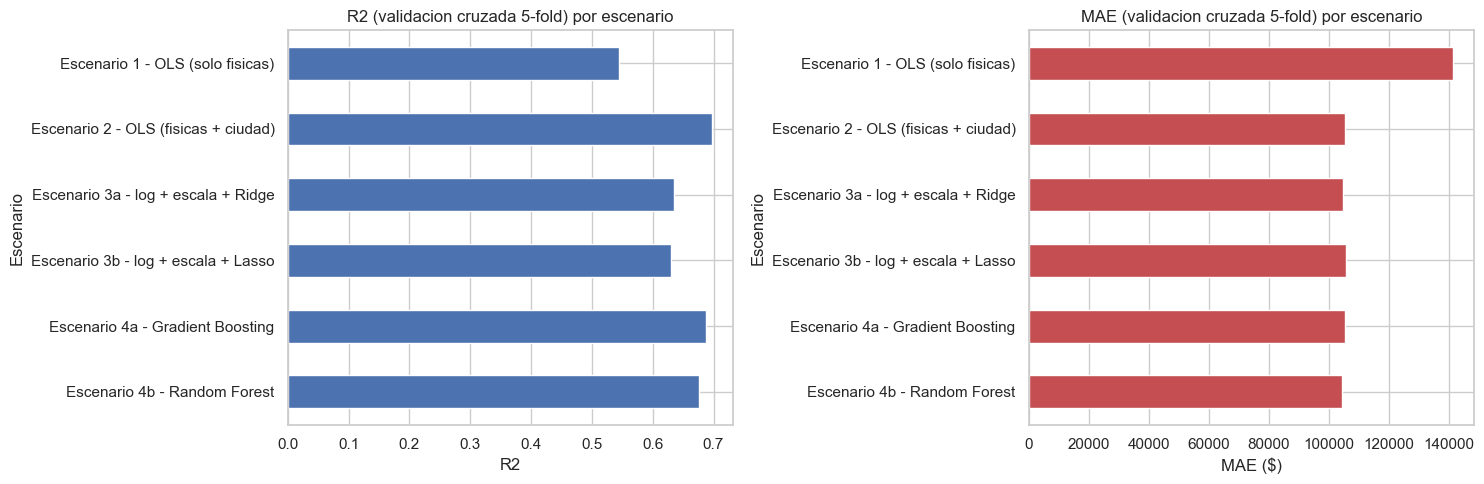

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tabla["R2 (CV)"].plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("R2 (validacion cruzada 5-fold) por escenario")
axes[0].set_xlabel("R2"); axes[0].invert_yaxis()

tabla["MAE (CV)"].plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("MAE (validacion cruzada 5-fold) por escenario")
axes[1].set_xlabel("MAE ($)"); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

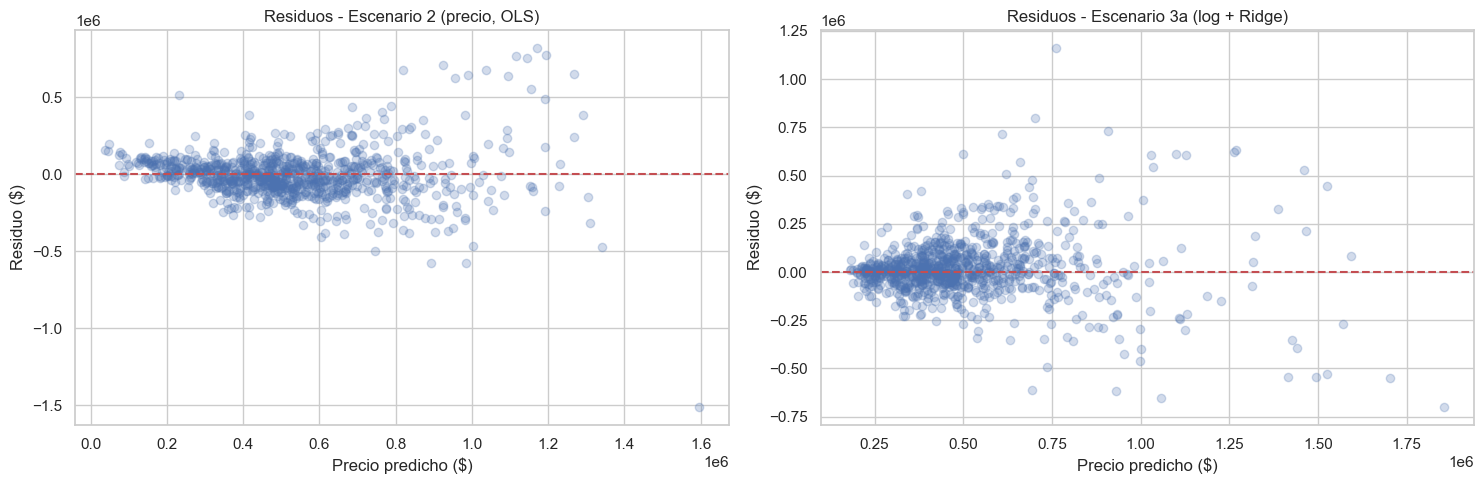

Al modelar log(price) los residuos quedan algo mas centrados y simetricos en las casas caras.


In [13]:
# Diagnostico del mejor modelo lineal (Escenario 3a: log + Ridge): residuos vs Escenario 2
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, pred, nombre in [(axes[0], pred_2, "Escenario 2 (precio, OLS)"),
                         (axes[1], pred_3r, "Escenario 3a (log + Ridge)")]:
    ax.scatter(pred, y_test - pred, alpha=0.25)
    ax.axhline(0, color="r", linestyle="--")
    ax.set_xlabel("Precio predicho ($)"); ax.set_ylabel("Residuo ($)")
    ax.set_title(f"Residuos - {nombre}")

plt.tight_layout(); plt.show()
print("Al modelar log(price) los residuos quedan algo mas centrados y simetricos en las casas caras.")

### Conclusiones de la Fase 1

Comparando los cuatro escenarios bajo la misma evaluación (hold-out + CV 5-fold)
extraemos cuatro conclusiones:

1. **Lo que más mejora el modelo es la información, no el algoritmo.** Pasar del
   Escenario 1 al 2 —simplemente añadiendo la ciudad— sube el R² (CV) de ≈ 0,55 a
   ≈ 0,70 y reduce el MAE un 25%. Ningún cambio de modelo posterior produce un salto
   comparable. La ubicación pesa tanto como toda la física de la vivienda.

2. **El preprocesado afina, no transforma.** Modelar `log(price)` logra el mejor MAE
   (≈ \$103k) al volver el error relativo y corregir la heterocedasticidad; el
   escalado es la condición que hace posible la regularización y permite **comparar
   coeficientes**, revelando que las ciudades de lujo dominan la estructura del precio.

3. **La regularización compra robustez e interpretabilidad.** Ridge estabiliza los
   coeficientes frente a la multicolinealidad de las superficies; Lasso entrega un
   modelo igual de bueno con ~20 variables menos (selección automática).

4. **El modelo lineal es defendible.** Los modelos no lineales (GB, RF) no lo superan:
   apenas hay señal no lineal con estas variables. Dado que el lineal es más
   interpretable y barato de desplegar, lo elegimos como **modelo de referencia**, con
   el Gradient Boosting como contraste de control.

**Modelo recomendado:** Escenario 3 (regresión lineal sobre `log(price)` con escalado
y regularización Ridge): mejor equilibrio entre error, estabilidad e interpretabilidad.
Las siguientes mejoras naturales —enriquecer la geografía con código postal o
coordenadas, y ajustar hiperparámetros con búsqueda en rejilla— se dejan planteadas
para una iteración posterior.

---
# Fase 2 — Primer diseño de la solución en la nube

La Fase 2 se entrega como **diagrama de arquitectura** (`arquitectura_cloud.png` /
`.pdf`) acompañado de una breve explicación. Resumen del planteamiento:

El modelo recomendado en la Fase 1 se industrializa sobre **Microsoft Azure** siguiendo
el patrón *MLOps* del **Azure Well-Architected Framework** y el **Cloud Adoption
Framework**: los datos de viviendas aterrizan en un **data lake en Azure Data Lake
Storage Gen2**, se limpian con **Azure Data Factory** (replicando el preprocesado de
este cuaderno), el modelo se entrena y versiona en **Azure Machine Learning** y se sirve
como **Managed Online Endpoint** consumido vía **API Management + Azure Functions**. La
seguridad (Entra ID + RBAC, Key Vault, VNet), la observabilidad (Azure Monitor +
data drift monitor de Azure ML) y el CI/CD (Azure DevOps) atraviesan toda la
arquitectura. Ver el diagrama y la justificación detallada en el archivo de entrega de
la Fase 2.